# Lab 4 — Two-Body Collisions

**Name:** James Kurschner 

**Date:** September 20, 2026


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4.5)


## Part A — 1D Collisions with Restitution


In [ ]:
def collide_1d(m1, m2, u1, u2, e):
    # Post-collision velocities from momentum conservation + restitution
    v1 = (m1*u1 + m2*u2 - m2*e*(u1-u2)) / (m1+m2)
    v2 = (m1*u1 + m2*u2 + m1*e*(u1-u2)) / (m1+m2)
    return v1, v2

def momentum_1d(m1, m2, v1, v2):
    return m1*v1 + m2*v2

def ke_1d(m1, m2, v1, v2):
    return 0.5*m1*v1**2 + 0.5*m2*v2**2


### Limiting-case checks


In [ ]:
tests = [
    ("Equal masses", 1.0, 1.0, 3.0, 0.0),
    ("Light into heavy", 0.1, 100.0, 5.0, 0.0),
    ("Heavy into light", 100.0, 0.1, 5.0, 0.0),
]

for label, m1, m2, u1, u2 in tests:
    v1, v2 = collide_1d(m1, m2, u1, u2, e=1.0)
    print(f"{label:18s}: v1 = {v1: .6f} m/s, v2 = {v2: .6f} m/s")


Equal masses      : v1 =  0.000000 m/s, v2 =  3.000000 m/s
Light into heavy  : v1 = -4.990010 m/s, v2 =  0.009990 m/s
Heavy into light  : v1 =  4.990010 m/s, v2 =  9.990010 m/s


In [ ]:
# Conservation check for the required 2 kg and 3 kg case
m1, m2 = 2.0, 3.0
u1, u2 = 4.0, 0.0

for e in [1.0, 0.5, 0.0]:
    v1, v2 = collide_1d(m1, m2, u1, u2, e)
    print(
        f"e={e:.1f} | "
        f"p before={momentum_1d(m1,m2,u1,u2):.3f}, "
        f"p after={momentum_1d(m1,m2,v1,v2):.3f}, "
        f"KE before={ke_1d(m1,m2,u1,u2):.3f}, "
        f"KE after={ke_1d(m1,m2,v1,v2):.3f}"
    )


e=1.0 | p before=8.000, p after=8.000, KE before=16.000, KE after=16.000
e=0.5 | p before=8.000, p after=8.000, KE before=16.000, KE after=8.800
e=0.0 | p before=8.000, p after=8.000, KE before=16.000, KE after=6.400


### Conservation table

| \(e\) | Momentum before (kg·m/s) | Momentum after (kg·m/s) | KE before (J) | KE after (J) |
|---:|---:|---:|---:|---:|
| 1.0 | 8.000 | 8.000 | 16.000 | 16.000 |
| 0.5 | 8.000 | 8.000 | 16.000 | 8.800 |
| 0.0 | 8.000 | 8.000 | 16.000 | 6.400 |

Momentum stays the same for every value of \(e\), but kinetic energy decreases for inelastic collisions. The missing kinetic energy is converted into things like deformation, sound, heat, and other internal energy.

## Part B — 2D Collisions in a Box


In [ ]:
def total_momentum(bodies):
    p = np.zeros(2)
    for b in bodies:
        p += b["m"] * b["v"]
    return p

def total_ke(bodies):
    return sum(0.5*b["m"]*np.dot(b["v"], b["v"]) for b in bodies)

def collide_2d(b1, b2, e=1.0):
    dr = b2["r"] - b1["r"]
    dist = np.linalg.norm(dr)
    if dist == 0:
        return

    n = dr / dist

    # Normal velocity components
    u1n = np.dot(b1["v"], n)
    u2n = np.dot(b2["v"], n)

    v1n, v2n = collide_1d(b1["m"], b2["m"], u1n, u2n, e)

    # Only change the normal component
    b1["v"] += (v1n - u1n) * n
    b2["v"] += (v2n - u2n) * n

def handle_walls(body, W, H):
    R = body["radius"]
    x, y = body["r"]

    if x - R < 0:
        body["r"][0] = R
        body["v"][0] = abs(body["v"][0])
    elif x + R > W:
        body["r"][0] = W - R
        body["v"][0] = -abs(body["v"][0])

    if y - R < 0:
        body["r"][1] = R
        body["v"][1] = abs(body["v"][1])
    elif y + R > H:
        body["r"][1] = H - R
        body["v"][1] = -abs(body["v"][1])

def copy_bodies(bodies):
    return [
        {
            "m": b["m"],
            "r": np.array(b["r"], dtype=float).copy(),
            "v": np.array(b["v"], dtype=float).copy(),
            "radius": b["radius"],
        }
        for b in bodies
    ]


In [ ]:
def simulate_box(initial_bodies, W=10.0, H=6.0, dt=0.01, tmax=8.0, e=1.0):
    bodies = copy_bodies(initial_bodies)
    nsteps = int(tmax/dt)

    times = np.arange(nsteps + 1) * dt
    paths = [[b["r"].copy()] for b in bodies]
    momenta = [total_momentum(bodies)]
    energies = [total_ke(bodies)]
    collision_events = []

    for _ in range(nsteps):
        # No continuous force in this lab, so Euler-Cromer reduces to r += v*dt.
        for b in bodies:
            b["r"] += b["v"] * dt
            handle_walls(b, W, H)

        # Check the one unique ball-ball pair
        b1, b2 = bodies
        dr = b2["r"] - b1["r"]
        dist = np.linalg.norm(dr)
        touching = dist < (b1["radius"] + b2["radius"])
        approaching = np.dot(b2["v"] - b1["v"], dr) < 0

        if touching and approaching:
            ke_before = total_ke(bodies)
            collide_2d(b1, b2, e=e)
            ke_after = total_ke(bodies)
            collision_events.append((ke_before, ke_after))

        for i, b in enumerate(bodies):
            paths[i].append(b["r"].copy())
        momenta.append(total_momentum(bodies))
        energies.append(total_ke(bodies))

    return (
        times,
        [np.array(p) for p in paths],
        np.array(momenta),
        np.array(energies),
        collision_events,
    )


In [ ]:
# Two balls of different masses and radii
initial_bodies_B = [
    {"m": 1.0, "r": np.array([2.0, 3.0]), "v": np.array([2.0, 0.35]), "radius": 0.35},
    {"m": 2.0, "r": np.array([7.0, 3.0]), "v": np.array([-1.0, 0.35]), "radius": 0.50},
]

W, H = 10.0, 6.0
tB, pathsB, pB, keB, eventsB = simulate_box(
    initial_bodies_B, W=W, H=H, dt=0.01, tmax=8.0, e=1.0
)

print("Ball-ball collisions detected:", len(eventsB))
print("Maximum relative KE drift:", np.max(np.abs(keB-keB[0]))/keB[0])


Ball-ball collisions detected: 2
Maximum relative KE drift: 0.0


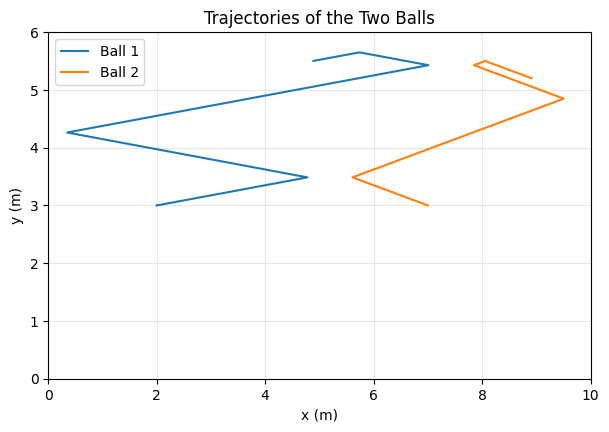

In [ ]:
# Trajectory plot
plt.figure()
plt.plot(pathsB[0][:,0], pathsB[0][:,1], label="Ball 1")
plt.plot(pathsB[1][:,0], pathsB[1][:,1], label="Ball 2")
plt.xlim(0, W)
plt.ylim(0, H)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Trajectories of the Two Balls")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


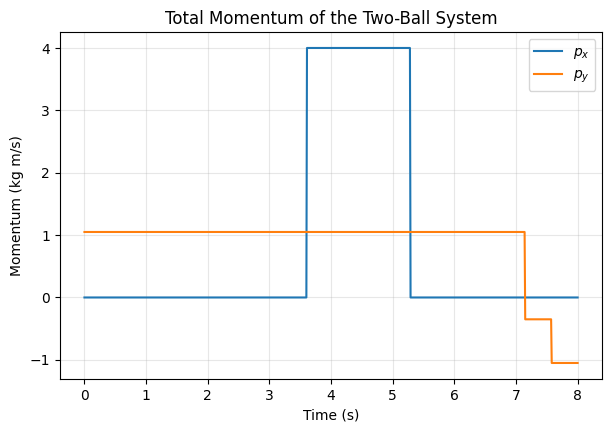

In [ ]:
# Total momentum components
plt.figure()
plt.plot(tB, pB[:,0], label="$p_x$")
plt.plot(tB, pB[:,1], label="$p_y$")
plt.xlabel("Time (s)")
plt.ylabel("Momentum (kg m/s)")
plt.title("Total Momentum of the Two-Ball System")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


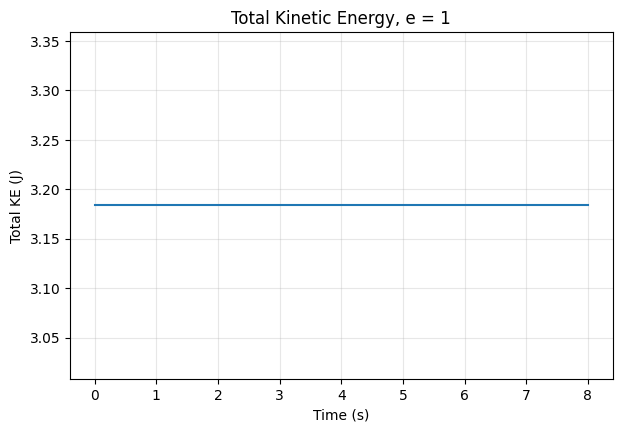

In [ ]:
# Total kinetic energy
plt.figure()
plt.plot(tB, keB)
plt.xlabel("Time (s)")
plt.ylabel("Total KE (J)")
plt.title("Total Kinetic Energy, e = 1")
plt.grid(alpha=0.3)
plt.show()


### Part B interpretation

For e=1, the total kinetic energy ought to stay constant because both the ball-ball collisions and wall collisions are elastic. The KE plot stays essentially flat

The total momentum of just the two balls does not have to stay constant when a ball hits a wall. The wall gives the ball an external impulse and reverses one component of its momentum. If the walls and Earth were incorporated as well, momentum would still have to be conserved.

## Part C — Inelastic Collisions and Energy Accounting

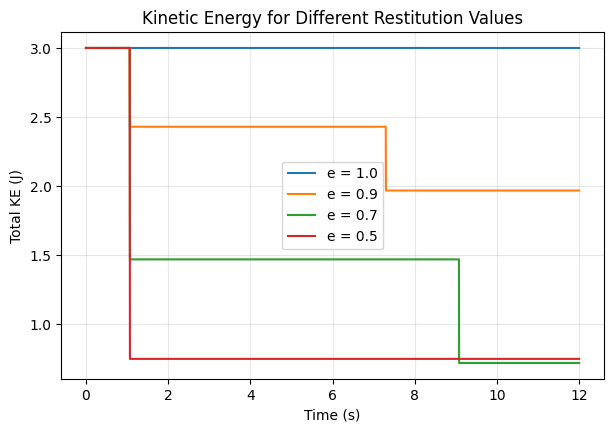

In [ ]:
initial_bodies_C = [
    {"m": 1.0, "r": np.array([3.0, 3.0]), "v": np.array([2.0, 0.0]), "radius": 0.40},
    {"m": 2.0, "r": np.array([7.0, 3.0]), "v": np.array([-1.0, 0.0]), "radius": 0.40},
]

e_values = [1.0, 0.9, 0.7, 0.5]
results_C = {}

plt.figure()
for e in e_values:
    result = simulate_box(initial_bodies_C, W=10.0, H=6.0, dt=0.005, tmax=12.0, e=e)
    results_C[e] = result
    t, paths, p, ke, events = result
    plt.plot(t, ke, label=f"e = {e}")

plt.xlabel("Time (s)")
plt.ylabel("Total KE (J)")
plt.title("Kinetic Energy for Different Restitution Values")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
print(" e    simulation loss fraction    theory (1-e^2)")
print("---------------------------------------------------")

for e in e_values:
    events = results_C[e][4]
    ke_before, ke_after = events[0]
    sim_fraction = (ke_before - ke_after) / ke_before
    theory_fraction = 1 - e**2
    print(f"{e:3.1f}          {sim_fraction:8.5f}            {theory_fraction:8.5f}")


 e    simulation loss fraction    theory (1-e^2)
---------------------------------------------------
1.0           0.00000             0.00000
0.9           0.19000             0.19000
0.7           0.51000             0.51000
0.5           0.75000             0.75000


The simulation matches the theoretical first-collision loss pretty well. As e gets progressively smaller, more of the kinetic energy is taken out of the translational motion.

### Center-of-mass test with no walls


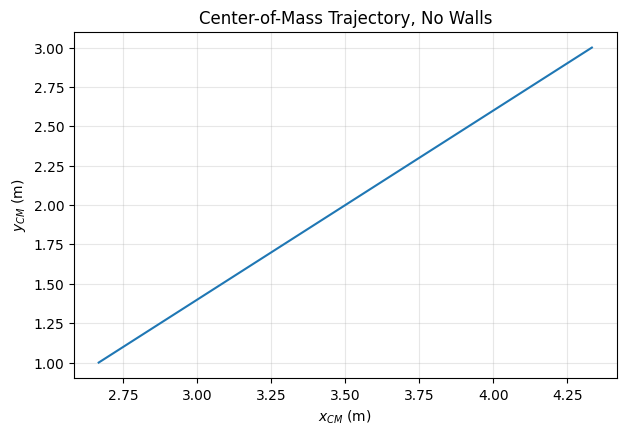

Center-of-mass velocity: [0.33333333 0.4       ]
Maximum deviation from straight-line prediction: 2.224439261476653e-14


In [ ]:
def simulate_no_walls(initial_bodies, dt=0.01, tmax=5.0, e=1.0):
    bodies = copy_bodies(initial_bodies)
    nsteps = int(tmax/dt)

    times = np.arange(nsteps + 1) * dt
    com_history = []

    def center_of_mass(bs):
        M = sum(b["m"] for b in bs)
        return sum((b["m"]*b["r"] for b in bs), np.zeros(2)) / M

    com_history.append(center_of_mass(bodies))

    for _ in range(nsteps):
        for b in bodies:
            b["r"] += b["v"] * dt

        b1, b2 = bodies
        dr = b2["r"] - b1["r"]
        touching = np.linalg.norm(dr) < (b1["radius"] + b2["radius"])
        approaching = np.dot(b2["v"] - b1["v"], dr) < 0

        if touching and approaching:
            collide_2d(b1, b2, e=e)

        com_history.append(center_of_mass(bodies))

    return times, np.array(com_history)

initial_com_test = [
    {"m": 1.0, "r": np.array([0.0, 1.0]), "v": np.array([2.0, 0.4]), "radius": 0.35},
    {"m": 2.0, "r": np.array([4.0, 1.0]), "v": np.array([-0.5, 0.4]), "radius": 0.35},
]

tcom, com = simulate_no_walls(initial_com_test, dt=0.01, tmax=5.0, e=1.0)

plt.figure()
plt.plot(com[:,0], com[:,1])
plt.xlabel("$x_{CM}$ (m)")
plt.ylabel("$y_{CM}$ (m)")
plt.title("Center-of-Mass Trajectory, No Walls")
plt.grid(alpha=0.3)
plt.show()

# Compare the measured COM path to a straight-line prediction
M = sum(b["m"] for b in initial_com_test)
r0 = sum((b["m"]*b["r"] for b in initial_com_test), np.zeros(2)) / M
vcm = total_momentum(initial_com_test) / M
predicted = r0 + tcom[:,None]*vcm

max_com_error = np.max(np.linalg.norm(com - predicted, axis=1))
print("Center-of-mass velocity:", vcm)
print("Maximum deviation from straight-line prediction:", max_com_error)


### Does KE ever increase for \(e<1\)?

For an inelastic collision, kinetic energy can stay constant between collisions and drop during a collision, but it should not increase. I checked the energy changes using a small step size.

In [ ]:
tol = 1e-10

for e in [0.9, 0.7, 0.5]:
    ke = results_C[e][3]
    increases = np.sum(np.diff(ke) > tol)
    largest_increase = np.max(np.diff(ke))
    print(f"e={e:.1f}: increases above tolerance = {increases}, largest step change = {largest_increase:.3e} J")


e=0.9: increases above tolerance = 0, largest step change = 0.000e+00 J
e=0.7: increases above tolerance = 0, largest step change = 0.000e+00 J
e=0.5: increases above tolerance = 0, largest step change = 0.000e+00 J


### Final analysis

For e<1, my total kinetic energy never increases past numerical cut-off. It stays flat while the balls move without resistance or bounce elastically off of the walls, then drops when the balls have are made to be inelastic. If the KE increased noticeably during an inelastic collision, then that might be a bug in hte system.

I think this test is overall very useful. With e less than or equal to 1 the collision cannot create translational kinetic energy.